# GE338 Lab 5 – Feasibility Notebook
## Mars on Earth: Northeastern Thailand Drought and Low Vegetation Mapping

Notebook นี้ออกแบบให้รันบน **Google Colab** โดยใช้ **shapefile จาก Google Drive** และแก้ปัญหา geometry payload ของ Earth Engine ด้วยการ `dissolve()`, `buffer(0)`, `simplify()`, และใช้ `bounds()` สำหรับการ query image collections

In [1]:
# ==============================
# 1) Install packages
# ==============================
!pip -q install earthengine-api geemap geopandas shapely fiona pyproj matplotlib pandas

In [2]:
# ==============================
# 2) Mount Google Drive
# ==============================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ==============================
# 3) Initialize Earth Engine
# ==============================
import ee
import geemap

PROJECT_ID = "ee-suranajkrua165"  # แก้เป็น project ของคุณ

try:
    ee.Initialize(project=PROJECT_ID)
    print(f"Earth Engine initialized with project: {PROJECT_ID}")
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print(f"Earth Engine initialized after authentication with project: {PROJECT_ID}")

Earth Engine initialized after authentication with project: ee-suranajkrua165


## ตั้งค่า path ของ shapefile
ใส่ path ให้ตรงกับไฟล์ใน Google Drive โดยใช้ไฟล์ `.shp` เป็นตัวอ้างอิงหลัก และต้องมี `.shx`, `.dbf`, `.prj` อยู่ในโฟลเดอร์เดียวกัน

In [4]:
# ==============================
# 4) Read shapefile from Google Drive
# ==============================
import geopandas as gpd
from shapely.geometry import mapping

SHP_PATH = "/content/drive/MyDrive/ISAN/ISAN.shp"   # แก้ path ตรงนี้
gdf = gpd.read_file(SHP_PATH)

print("Original CRS:", gdf.crs)
print("Original feature count:", len(gdf))
gdf.head()

Original CRS: EPSG:32647
Original feature count: 20


,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM1ALT1TH,ADM1ALT2TH,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
0,3.927244,0.275313,Amnat Charoen,อำนาจเจริญ,TH37,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((1137719.888 1809628.932, 1137724.275..."
1,4.414998,0.340784,Bueng Kan,บึงกาฬ,TH38,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((965496.027 2045531.181, 965625.512 2..."
2,8.701860,0.844537,Buri Ram,บุรีรัมย์,TH31,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((921217.023 1750211.599, 921217.028 1..."
3,7.055513,1.065319,Chaiyaphum,ชัยภูมิ,TH36,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((772997.438 1851276.375, 773104.5 185..."
4,6.054797,0.583378,Kalasin,กาฬสินธุ์,TH46,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((988114.511 1896346.757, 988166.358 1..."


In [5]:
# ==============================
# 5) Clean geometry for Earth Engine
# ==============================
# แปลงพิกัดเป็น WGS84
gdf = gdf.to_crs(epsg=4326)

# รวม polygon ทุกชิ้นเป็น geometry เดียว
gdf_union = gdf.dissolve().reset_index(drop=True)

# ซ่อม geometry กรณีมี invalid geometry
gdf_union["geometry"] = gdf_union.buffer(0)

# simplify เพื่อลดจำนวนจุดและแก้ payload issue
SIMPLIFY_TOL = 0.01
gdf_union["geometry"] = gdf_union.geometry.simplify(SIMPLIFY_TOL, preserve_topology=True)

print(gdf_union)
print("Geometry simplified successfully.")

                                            geometry  Shape_Leng  Shape_Area  \
0  POLYGON ((104.05708 14.34343, 103.97884 14.353...    3.927244    0.275313   

         ADM1_EN     ADM1_TH ADM1_PCODE ADM1_REF ADM1ALT1EN ADM1ALT2EN  \
0  Amnat Charoen  อำนาจเจริญ       TH37     None       None       None   

  ADM1ALT1TH ADM1ALT2TH   ADM0_EN    ADM0_TH ADM0_PCODE       date    validOn  \
0       None       None  Thailand  ประเทศไทย         TH 2019-02-18 2019-02-21   

  validTo  
0     NaT  
Geometry simplified successfully.


In [6]:
# ==============================
# 6) Convert to Earth Engine safely
# ==============================
geom_json = mapping(gdf_union.geometry.iloc[0])

isan_fc = ee.FeatureCollection([
    ee.Feature(ee.Geometry(geom_json), {"name": "ISAN"})
])

# ใช้ bounds เพื่อลดภาระในการ filterBounds
isan_bounds = isan_fc.geometry().bounds()

print("EE feature count:", isan_fc.size().getInfo())

EE feature count: 1


In [7]:
# ==============================
# 7) Visualize study area
# ==============================
Map = geemap.Map()
Map.centerObject(isan_fc, 7)
Map.addLayer(isan_fc, {"color": "red"}, "ISAN boundary")
Map

Map(center=[16.09262410197408, 103.24551549326085], controls=(WidgetControl(options=['position', 'transparent_…

In [8]:
# ==============================
# 8) Parameters
# ==============================
START_YEAR = 2001
END_YEAR = 2024
TARGET_YEAR = 2024

start_date = f"{START_YEAR}-01-01"
end_date = f"{END_YEAR}-12-31"

In [9]:
# ==============================
# 9) Load image collections
# ==============================
ndvi_ic = ee.ImageCollection("MODIS/061/MOD13Q1")
et_ic = ee.ImageCollection("MODIS/061/MOD16A2GF")
rain_ic = ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07")
lst_ic = ee.ImageCollection("MODIS/061/MOD11A2")
dem = ee.Image("USGS/SRTMGL1_003")

print("NDVI images:", ndvi_ic.filterDate(start_date, end_date).filterBounds(isan_bounds).size().getInfo())
print("ET images:", et_ic.filterDate(start_date, end_date).filterBounds(isan_bounds).size().getInfo())
print("Rain images:", rain_ic.filterDate(start_date, end_date).filterBounds(isan_bounds).size().getInfo())
print("LST images:", lst_ic.filterDate(start_date, end_date).filterBounds(isan_bounds).size().getInfo())

NDVI images: 552
ET images: 1104
Rain images: 288
LST images: 1103


In [10]:
# ==============================
# 10) Annual metrics function
# ==============================
def annual_metrics(year):
    year = ee.Number(year).toInt()
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    ndvi = (
        ndvi_ic.filterDate(start, end)
        .filterBounds(isan_bounds)
        .select("NDVI")
        .mean()
        .multiply(0.0001)
        .rename("NDVI")
    )

    et = (
        et_ic.filterDate(start, end)
        .filterBounds(isan_bounds)
        .select("ET")
        .sum()
        .multiply(0.1)
        .rename("ET")
    )

    rain = (
        rain_ic.filterDate(start, end)
        .filterBounds(isan_bounds)
        .select("precipitation")
        .sum()
        .rename("P")
    )

    lst = (
        lst_ic.filterDate(start, end)
        .filterBounds(isan_bounds)
        .select("LST_Day_1km")
        .mean()
        .multiply(0.02)
        .subtract(273.15)
        .rename("LST_C")
    )

    ai = rain.divide(et.add(1e-6)).rename("AI")
    dryness = ee.Image(1).subtract(ai.unitScale(0, 2).clamp(0, 1)).rename("Dryness")
    low_veg = ee.Image(1).subtract(ndvi.unitScale(0, 1).clamp(0, 1)).rename("LowVeg")
    mdi = low_veg.add(dryness).divide(2).rename("MDI")

    mdi_class = (
        ee.Image(0)
        .where(mdi.gte(0.33).And(mdi.lt(0.66)), 1)
        .where(mdi.gte(0.66), 2)
        .rename("MDI_Class")
    )

    out = (
        ndvi.addBands(et)
        .addBands(rain)
        .addBands(lst)
        .addBands(ai)
        .addBands(dryness)
        .addBands(low_veg)
        .addBands(mdi)
        .addBands(mdi_class)
        .clip(isan_fc)
        .set("year", year)
        .set("system:time_start", start.millis())
    )

    return out

In [11]:
# ==============================
# 11) Create annual image collection
# ==============================
years = ee.List.sequence(START_YEAR, END_YEAR)
annual_ic = ee.ImageCollection(years.map(annual_metrics))
print("Annual images:", annual_ic.size().getInfo())

target_img = annual_ic.filter(ee.Filter.eq("year", TARGET_YEAR)).first()

Annual images: 24


In [12]:
# ==============================
# 12) Visualization parameters
# ==============================
ndvi_vis = {"min": 0.0, "max": 0.8, "palette": ["brown", "yellow", "green"]}
dry_vis = {"min": 0.0, "max": 1.0, "palette": ["blue", "orange", "red"]}
mdi_vis = {"min": 0.0, "max": 1.0, "palette": ["#2c7bb6", "#ffffbf", "#d7191c"]}
class_vis = {"min": 0, "max": 2, "palette": ["#66bd63", "#fdae61", "#d73027"]}
dem_vis = {"min": 0, "max": 1000}

In [13]:
# ==============================
# 13) Map layers
# ==============================
Map = geemap.Map()
Map.centerObject(isan_fc, 7)
Map.addLayer(target_img.select("NDVI"), ndvi_vis, f"NDVI {TARGET_YEAR}")
Map.addLayer(target_img.select("Dryness"), dry_vis, f"Dryness {TARGET_YEAR}")
Map.addLayer(target_img.select("MDI"), mdi_vis, f"MDI {TARGET_YEAR}")
Map.addLayer(target_img.select("MDI_Class"), class_vis, f"MDI Class {TARGET_YEAR}")
Map.addLayer(dem.clip(isan_fc), dem_vis, "DEM")
Map.addLayer(isan_fc, {"color": "black"}, "Boundary")

Map.add_colorbar(ndvi_vis, label=f"NDVI {TARGET_YEAR}", layer_name=f"NDVI {TARGET_YEAR}")
Map.add_colorbar(dry_vis, label=f"Dryness {TARGET_YEAR}", layer_name=f"Dryness {TARGET_YEAR}")
Map.add_colorbar(mdi_vis, label=f"MDI {TARGET_YEAR}", layer_name=f"MDI {TARGET_YEAR}")

Map

Map(center=[16.092624101974096, 103.24551549326085], controls=(WidgetControl(options=['position', 'transparent…

In [14]:
# ==============================
# 14) Annual summary table
# ==============================
def annual_stats(img):
    stats = img.select(["NDVI", "AI", "Dryness", "MDI", "LST_C"]).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=isan_fc.geometry(),
        scale=500,
        maxPixels=1e13,
        bestEffort=True
    )
    return ee.Feature(None, {
        "year": img.get("year"),
        "NDVI_mean": stats.get("NDVI"),
        "AI_mean": stats.get("AI"),
        "Dryness_mean": stats.get("Dryness"),
        "MDI_mean": stats.get("MDI"),
        "LST_C_mean": stats.get("LST_C")
    })

stats_fc = ee.FeatureCollection(annual_ic.map(annual_stats))
print("Stats rows:", stats_fc.size().getInfo())

Stats rows: 24


In [15]:
# ==============================
# 15) Convert stats to pandas
# ==============================
import pandas as pd
stats_dict = stats_fc.getInfo()
rows = [f["properties"] for f in stats_dict["features"]]
df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
df.head()

,AI_mean,Dryness_mean,LST_C_mean,MDI_mean,NDVI_mean,year
0,0.002708,0.998646,31.758995,0.745511,0.503562,2001
1,0.002906,0.998547,31.831310,0.743848,0.506820,2002
2,0.002332,0.998834,32.011893,0.730575,0.533384,2003
3,0.002799,0.998601,32.353289,0.749100,0.496618,2004
4,0.002536,0.998732,32.484441,0.754799,0.485507,2005


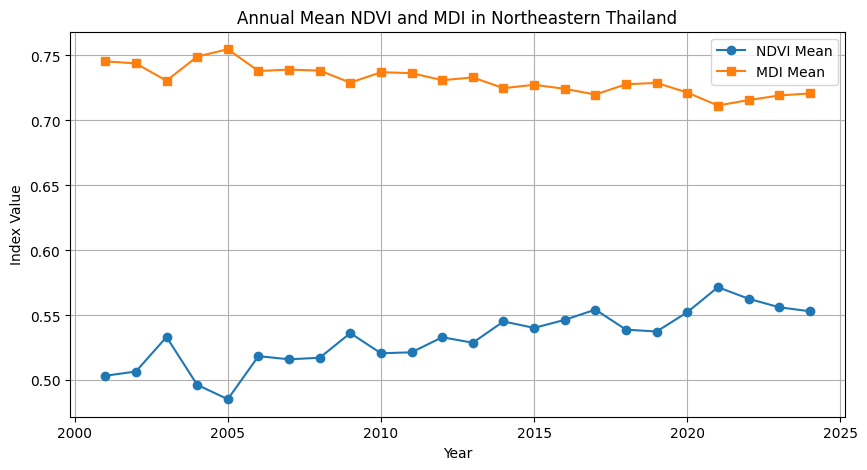

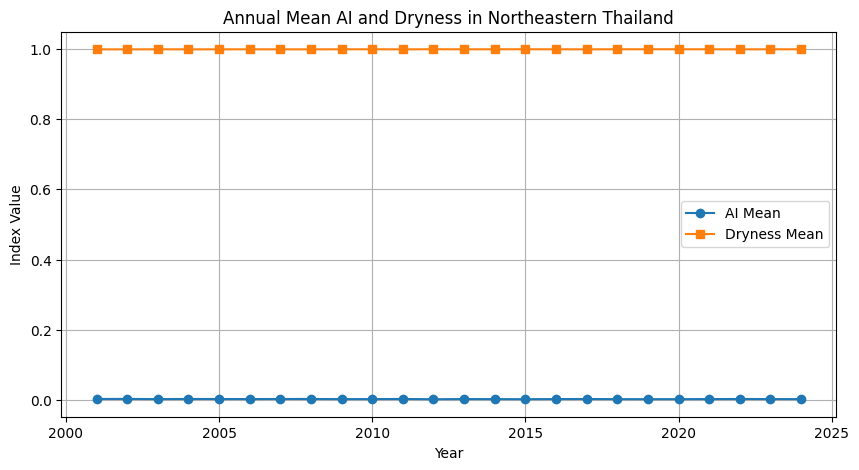

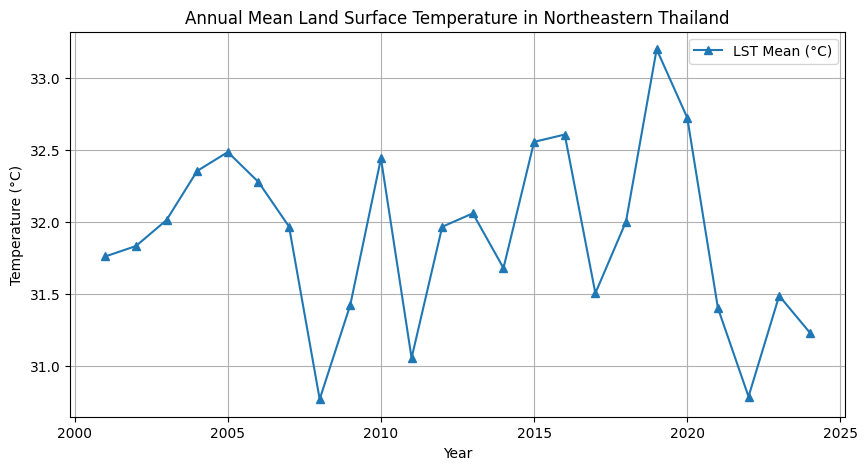

In [16]:
# ==============================
# 16) Time series plots
# ==============================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["year"], df["NDVI_mean"], marker="o", label="NDVI Mean")
plt.plot(df["year"], df["MDI_mean"], marker="s", label="MDI Mean")
plt.xlabel("Year")
plt.ylabel("Index Value")
plt.title("Annual Mean NDVI and MDI in Northeastern Thailand")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["year"], df["AI_mean"], marker="o", label="AI Mean")
plt.plot(df["year"], df["Dryness_mean"], marker="s", label="Dryness Mean")
plt.xlabel("Year")
plt.ylabel("Index Value")
plt.title("Annual Mean AI and Dryness in Northeastern Thailand")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["year"], df["LST_C_mean"], marker="^", label="LST Mean (°C)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Annual Mean Land Surface Temperature in Northeastern Thailand")
plt.legend()
plt.grid(True)
plt.show()

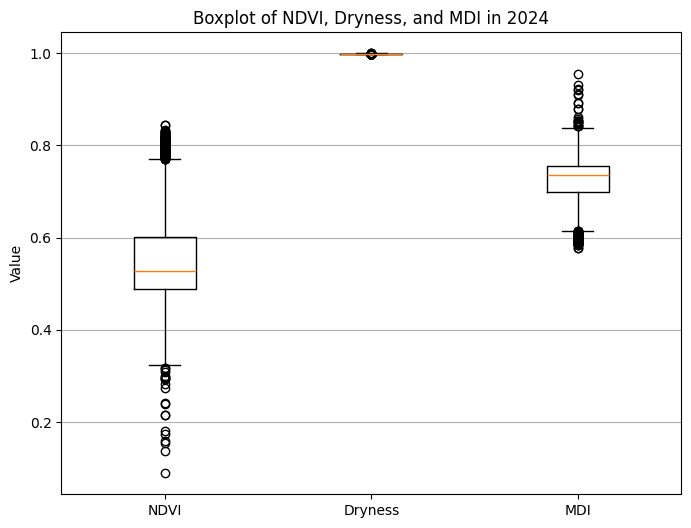

In [17]:
# ==============================
# 17) Pixel sampling and boxplot
# ==============================
sample_fc = target_img.select(["NDVI", "Dryness", "MDI"]).sample(
    region=isan_fc.geometry(),
    scale=1000,
    numPixels=5000,
    geometries=False,
    seed=42
)

sample_info = sample_fc.getInfo()
sample_rows = [f["properties"] for f in sample_info["features"]]
sample_df = pd.DataFrame(sample_rows)

plt.figure(figsize=(8, 6))
plt.boxplot(
    [sample_df["NDVI"].dropna(), sample_df["Dryness"].dropna(), sample_df["MDI"].dropna()],
    tick_labels=["NDVI", "Dryness", "MDI"]
)
plt.title(f"Boxplot of NDVI, Dryness, and MDI in {TARGET_YEAR}")
plt.ylabel("Value")
plt.grid(True, axis="y")
plt.show()

In [18]:
# ==============================
# 18) Area by class
# ==============================
area_img = ee.Image.pixelArea().divide(1e6).rename("area_km2")
class_img = target_img.select("MDI_Class")

area_by_class = area_img.addBands(class_img).reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName="class"),
    geometry=isan_fc.geometry(),
    scale=1000,
    maxPixels=1e13,
    bestEffort=True
)

groups = area_by_class.getInfo()["groups"]
area_df = pd.DataFrame(groups)
area_df["class_name"] = area_df["class"].map({
    0: "Low Mars-like",
    1: "Moderate Mars-like",
    2: "High Mars-like"
})
area_df = area_df.rename(columns={"sum": "area_km2"})
area_df

,class,area_km2,class_name
0,0,1353.629897,Low Mars-like
1,1,22796.120748,Moderate Mars-like
2,2,142768.591937,High Mars-like


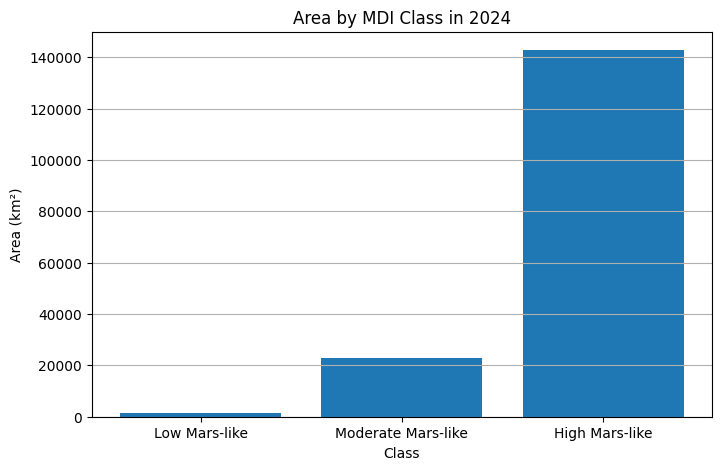

In [19]:
# ==============================
# 19) Bar chart of class areas
# ==============================
plt.figure(figsize=(8, 5))
plt.bar(area_df["class_name"], area_df["area_km2"])
plt.title(f"Area by MDI Class in {TARGET_YEAR}")
plt.xlabel("Class")
plt.ylabel("Area (km²)")
plt.grid(True, axis="y")
plt.show()

In [20]:
# ==============================
# 20) Save outputs
# ==============================
output_csv = f"/content/drive/MyDrive/isan_annual_stats_{START_YEAR}_{END_YEAR}.csv"
df.to_csv(output_csv, index=False)
print("Saved CSV to:", output_csv)

geojson_path = "/content/drive/MyDrive/ISAN_simplified.geojson"
gdf_union.to_file(geojson_path, driver="GeoJSON")
print("Saved GeoJSON to:", geojson_path)

Saved CSV to: /content/drive/MyDrive/isan_annual_stats_2001_2024.csv
Saved GeoJSON to: /content/drive/MyDrive/ISAN_simplified.geojson


In [21]:
# ==============================
# 21) Export rasters to Google Drive
# ==============================
task_mdi = ee.batch.Export.image.toDrive(
    image=target_img.select("MDI").toFloat(),
    description=f"ISAN_MDI_{TARGET_YEAR}",
    folder="GEE_exports",
    fileNamePrefix=f"ISAN_MDI_{TARGET_YEAR}",
    region=isan_fc.geometry(),
    scale=1000,
    maxPixels=1e13,
    fileFormat="GeoTIFF"
)
task_mdi.start()

task_class = ee.batch.Export.image.toDrive(
    image=target_img.select("MDI_Class").toInt(),
    description=f"ISAN_MDI_Class_{TARGET_YEAR}",
    folder="GEE_exports",
    fileNamePrefix=f"ISAN_MDI_Class_{TARGET_YEAR}",
    region=isan_fc.geometry(),
    scale=1000,
    maxPixels=1e13,
    fileFormat="GeoTIFF"
)
task_class.start()

print("MDI export task:", task_mdi.status())
print("MDI Class export task:", task_class.status())

MDI export task: {'state': 'READY', 'description': 'ISAN_MDI_2024', 'priority': 100, 'creation_timestamp_ms': 1775112215455, 'update_timestamp_ms': 1775112215455, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'P35NOG272HGCOEVZGXTSOKQW', 'name': 'projects/ee-suranajkrua165/operations/P35NOG272HGCOEVZGXTSOKQW'}
MDI Class export task: {'state': 'READY', 'description': 'ISAN_MDI_Class_2024', 'priority': 100, 'creation_timestamp_ms': 1775112215976, 'update_timestamp_ms': 1775112215976, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': '4FOLHLGYFP3Q3XCY5BRWRZDA', 'name': 'projects/ee-suranajkrua165/operations/4FOLHLGYFP3Q3XCY5BRWRZDA'}


## หมายเหตุสำคัญ
- ห้ามใช้ `print(isan_fc.getInfo())` หรือ `print(isan_fc.geometry().getInfo())` เพราะจะดึง geometry ใหญ่กลับมาฝั่ง Python และอาจชน payload limit
- หากยังเจอปัญหา payload ให้เพิ่มค่า `SIMPLIFY_TOL` จาก `0.01` เป็น `0.02` หรือ `0.05`
- หาก shapefile ซับซ้อนมากจริง ๆ Plan B คืออัป zip shapefile เป็น Earth Engine Asset แล้วเรียกผ่าน `ee.FeatureCollection(asset_id)`